In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import torch
from PIL import Image, ImageDraw
import numpy as np
import pandas as pd
import re
import random
import json
import math

In [2]:
data_dir = Path('./data')

In [3]:
for item in sorted(data_dir.iterdir()):
    kind = "folder" if item.is_dir() else "file"
    print(f"{kind:6}  {item.name}")

folder  clean_dataset
folder  task_2061437_annotations_2026_05_27_14_09_03_segmentation mask 1.1
folder  Training_Images


In [8]:
image_dir = data_dir / "Training_Images"
mask_export_dir = next(
    folder for folder in data_dir.iterdir()
    if folder.is_dir() and "segmentation mask" in folder.name.lower()
)

segmentation_class_dir = mask_export_dir / "SegmentationClass"
segmentation_object_dir = mask_export_dir / "SegmentationObject"
labelmap_path = mask_export_dir / "labelmap.txt"

print("Image folder:", image_dir)
print("Image folder exists:", image_dir.exists())

print("\nMask export folder:", mask_export_dir)
print("SegmentationClass exists:", segmentation_class_dir.exists())
print("SegmentationObject exists:", segmentation_object_dir.exists())
print("Label map exists:", labelmap_path.exists())

print("\nLabel map:")
print(labelmap_path.read_text())

Image folder: data\Training_Images
Image folder exists: True

Mask export folder: data\task_2061437_annotations_2026_05_27_14_09_03_segmentation mask 1.1
SegmentationClass exists: True
SegmentationObject exists: True
Label map exists: True

Label map:
# label:color_rgb:parts:actions
background:0,0,0::
leaf:102,255,102::
stem:255,106,77::
unknown:184,61,245::



In [9]:
# Check images and mask matches

image_paths = sorted([
    p for p in image_dir.iterdir()
    if p.is_file() and p.suffix.lower() in [".jpg", ".png", ".jpeg"]
])

mask_paths = [
    p for p in segmentation_class_dir.rglob("*.png")
    if p.is_file()
]

image_stems = {p.stem for p in image_paths}
mask_stems = {p.stem for p in mask_paths}

matched_stems = sorted(image_stems & mask_stems)
images_without_masks = sorted(image_stems - mask_stems)
masks_without_images = sorted(mask_stems - image_stems)

print("Number of images:", len(image_paths))
print("Number of masks:", len(mask_paths))
print("Matched image-mask pairs:", len(matched_stems))

print("\nMasks without images:", len(masks_without_images))
print(masks_without_images[:10])

print("\nMasks without images:", len(masks_without_images))
print(masks_without_images[:10])

print("\nFirst 5 matched examples:")
for stem in matched_stems[:5]:
    image_path = next(p for p in image_paths if p.stem == stem)
    mask_path = next(p for p in mask_paths if p.stem == stem)
    print(stem)
    print("Image:", image_path)
    print("Mask:", mask_path)

Number of images: 70
Number of masks: 71
Matched image-mask pairs: 70

Masks without images: 1
['3ENT3VC7Q900006_cropped-checkpoint']

Masks without images: 1
['3ENT3VC7Q900006_cropped-checkpoint']

First 5 matched examples:
3ENT3VC7Q900005_cropped
Image: data\Training_Images\3ENT3VC7Q900005_cropped.JPG
Mask: data\task_2061437_annotations_2026_05_27_14_09_03_segmentation mask 1.1\SegmentationClass\3ENT3VC7Q900005_cropped.png
3ENT3VC7Q900006_cropped
Image: data\Training_Images\3ENT3VC7Q900006_cropped.JPG
Mask: data\task_2061437_annotations_2026_05_27_14_09_03_segmentation mask 1.1\SegmentationClass\3ENT3VC7Q900006_cropped.png
3N6I35BRZA00006_cropped
Image: data\Training_Images\3N6I35BRZA00006_cropped.JPG
Mask: data\task_2061437_annotations_2026_05_27_14_09_03_segmentation mask 1.1\SegmentationClass\3N6I35BRZA00006_cropped.png
3N6I35BRZA00007_cropped
Image: data\Training_Images\3N6I35BRZA00007_cropped.JPG
Mask: data\task_2061437_annotations_2026_05_27_14_09_03_segmentation mask 1.1\Segme

In [10]:
# create class mapping
label_name_map = {
    "unknown": "foreign_material"
}

classes = []
color_to_class_id = {}

for line in labelmap_path.read_text().splitlines():
    line = line.strip()
    
    if not line or line.startswith("#"):
        continue
    
    label_name, color_text, *_ = line.split(":")
    clean_label_name = label_name_map.get(label_name, label_name)
    
    rgb = tuple(int(value) for value in color_text.split(","))
    class_id = len(classes)
    
    classes.append({
        "id": class_id,
        "name": clean_label_name,
        "source_name": label_name,
        "rgb": rgb
    })
    
    color_to_class_id[rgb] = class_id

print("Classes:")
for cls in classes:
    print(cls)
    
print("\nColor to class id:")
for color, class_id in color_to_class_id.items():
    print(f"{color}: {class_id}")

Classes:
{'id': 0, 'name': 'background', 'source_name': 'background', 'rgb': (0, 0, 0)}
{'id': 1, 'name': 'leaf', 'source_name': 'leaf', 'rgb': (102, 255, 102)}
{'id': 2, 'name': 'stem', 'source_name': 'stem', 'rgb': (255, 106, 77)}
{'id': 3, 'name': 'foreign_material', 'source_name': 'unknown', 'rgb': (184, 61, 245)}

Color to class id:
(0, 0, 0): 0
(102, 255, 102): 1
(255, 106, 77): 2
(184, 61, 245): 3


In [11]:
# convert one mask and inspect it
sample_stem = matched_stems[0]

sample_image_path = next(p for p in image_paths if p.stem == sample_stem)
sample_mask_path = next(p for p in mask_paths if p.stem == sample_stem)

rgb_mask = Image.open(sample_mask_path).convert("RGB")
rgb_mask_array = np.array(rgb_mask)

class_id_mask = np.zeros(rgb_mask_array.shape[:2], dtype=np.uint8)

for rgb_color, class_id in color_to_class_id.items():
    matching_pixels = np.all(rgb_mask_array == rgb_color, axis=-1)
    class_id_mask[matching_pixels] = class_id
    
print("Sample:", sample_stem)
print("Image path:", sample_image_path)
print("Mask path:", sample_mask_path)
print("RGB mask shape:", rgb_mask_array.shape)
print("Class-ID mask shape:", class_id_mask.shape)
print("Unique class IDs in this mask:", np.unique(class_id_mask))

Sample: 3ENT3VC7Q900005_cropped
Image path: data\Training_Images\3ENT3VC7Q900005_cropped.JPG
Mask path: data\task_2061437_annotations_2026_05_27_14_09_03_segmentation mask 1.1\SegmentationClass\3ENT3VC7Q900005_cropped.png
RGB mask shape: (2000, 2000, 3)
Class-ID mask shape: (2000, 2000)
Unique class IDs in this mask: [1 2 3]


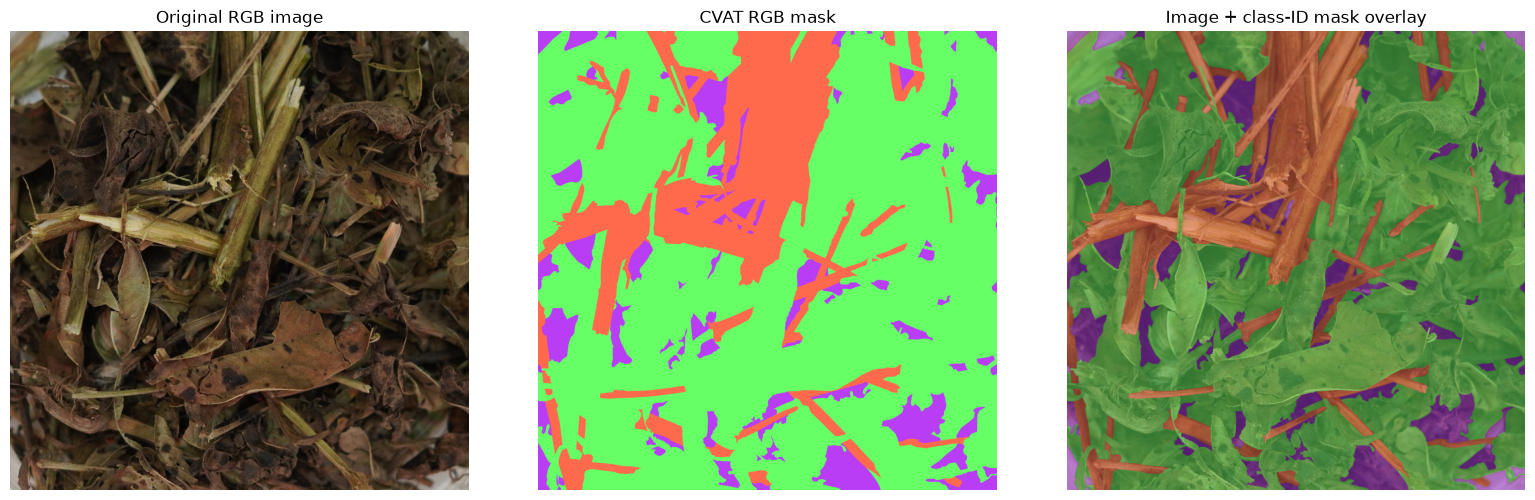

In [12]:
sample_image = Image.open(sample_image_path).convert("RGB")

# Colors for class IDs in order:
# 0 background, 1 leaf, 2 stem, 3 foreign_material
class_colors = [
    (0/255, 0/255, 0/255),          # background
    (102/255, 255/255, 102/255),    # leaf
    (255/255, 106/255, 77/255),     # stem
    (184/255, 61/255, 245/255),     # foreign material
]

class_cmap = ListedColormap(class_colors)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title("Original RGB image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(rgb_mask)
plt.title("CVAT RGB mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sample_image)
plt.imshow(class_id_mask, cmap=class_cmap, alpha=0.45, vmin=0, vmax=3)
plt.title("Image + class-ID mask overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# The height and width must be identical for a perfect 1:1 overlay
print("Image shape:", np.array(sample_image).shape[:2])
print("Mask shape:", class_id_mask.shape)

Image shape: (2000, 2000)
Mask shape: (2000, 2000)


In [14]:
prepared_dir = data_dir / "clean_dataset"
class_id_mask_dir = prepared_dir / "class_id_masks"
splits_dir = prepared_dir / "splits"

prepared_dir.mkdir(exist_ok=True)
class_id_mask_dir.mkdir(exist_ok=True)
splits_dir.mkdir(exist_ok=True)

print("Prepared dataset folder:", prepared_dir)
print("Class-ID mask folder:", class_id_mask_dir)
print("Splits folder:", splits_dir)

Prepared dataset folder: data\clean_dataset
Class-ID mask folder: data\clean_dataset\class_id_masks
Splits folder: data\clean_dataset\splits


In [15]:
def convert_rgb_mask_to_class_id_mask(rgb_mask_path, output_mask_path, color_to_class_id):
    rgb_mask = Image.open(rgb_mask_path).convert("RGB")
    rgb_mask_array = np.array(rgb_mask)

    class_id_mask = np.zeros(rgb_mask_array.shape[:2], dtype=np.uint8)
    matched_pixels = np.zeros(rgb_mask_array.shape[:2], dtype=bool)

    for rgb_color, class_id in color_to_class_id.items():
        matching_pixels = np.all(rgb_mask_array == rgb_color, axis=-1)
        class_id_mask[matching_pixels] = class_id
        matched_pixels |= matching_pixels

    if not matched_pixels.all():
        unknown_colors = np.unique(rgb_mask_array[~matched_pixels].reshape(-1, 3), axis=0)
        raise ValueError(
            f"Found unexpected colors in {rgb_mask_path}: {unknown_colors[:10]}"
        )

    Image.fromarray(class_id_mask).save(output_mask_path)
    return class_id_mask

converted_count = 0

for stem in matched_stems:
    mask_path = next(p for p in mask_paths if p.stem == stem)
    output_mask_path = class_id_mask_dir / f"{stem}.png"

    convert_rgb_mask_to_class_id_mask(
        rgb_mask_path=mask_path,
        output_mask_path=output_mask_path,
        color_to_class_id=color_to_class_id
    )

    converted_count += 1

print("Converted masks:", converted_count)
print("Saved to:", class_id_mask_dir)

Converted masks: 70
Saved to: data\clean_dataset\class_id_masks


In [16]:
converted_mask_path = class_id_mask_dir / f"{matched_stems[0]}.png"

converted_mask = Image.open(converted_mask_path)
converted_mask_array = np.array(converted_mask)

print("Converted mask path:", converted_mask_path)
print("Mode:", converted_mask.mode)
print("Shape:", converted_mask_array.shape)
print("Minimum pixel value:", converted_mask_array.min())
print("Maximum pixel value:", converted_mask_array.max())
print("Unique pixel values:", np.unique(converted_mask_array))

Converted mask path: data\clean_dataset\class_id_masks\3ENT3VC7Q900005_cropped.png
Mode: L
Shape: (2000, 2000)
Minimum pixel value: 1
Maximum pixel value: 3
Unique pixel values: [1 2 3]


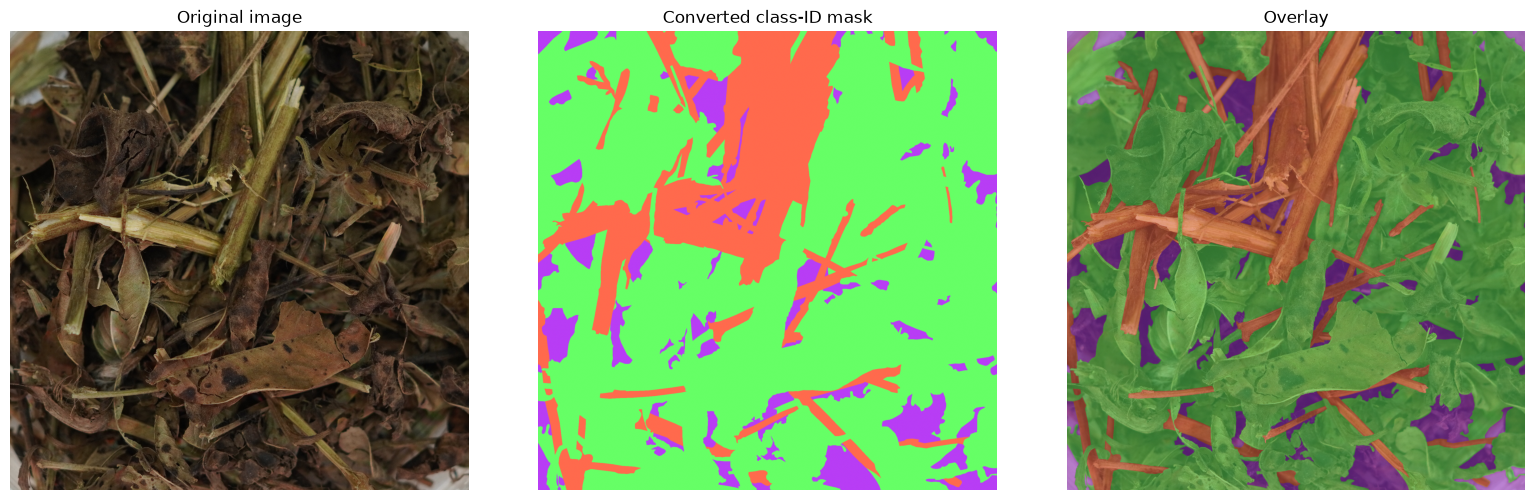

In [17]:
# Same class order:
# 0 = background
# 1 = leaf
# 2 = stem
# 3 = foreign_material
class_colors = [
    (0/255, 0/255, 0/255),          # background
    (102/255, 255/255, 102/255),    # leaf
    (255/255, 106/255, 77/255),     # stem
    (184/255, 61/255, 245/255),     # foreign material
]

class_cmap = ListedColormap(class_colors)

sample_image = Image.open(sample_image_path).convert("RGB")

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(converted_mask_array, cmap=class_cmap, vmin=0, vmax=3)
plt.title("Converted class-ID mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sample_image)
plt.imshow(converted_mask_array, cmap=class_cmap, alpha=0.45, vmin=0, vmax=3)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
classes

[{'id': 0,
  'name': 'background',
  'source_name': 'background',
  'rgb': (0, 0, 0)},
 {'id': 1, 'name': 'leaf', 'source_name': 'leaf', 'rgb': (102, 255, 102)},
 {'id': 2, 'name': 'stem', 'source_name': 'stem', 'rgb': (255, 106, 77)},
 {'id': 3,
  'name': 'foreign_material',
  'source_name': 'unknown',
  'rgb': (184, 61, 245)}]

In [19]:
# Dataset Manifest
rows = []

for stem in matched_stems:
    image_path = next(p for p in image_paths if p.stem == stem)
    class_id_mask_path = class_id_mask_dir / f"{stem}.png"
    
    mask_array = np.array(Image.open(class_id_mask_path))
    
    row = {
        "sample_id": stem,
        "image_path": str(image_path),
        "class_id_mask_path": str(class_id_mask_path),
        "width": mask_array.shape[1],
        "height": mask_array.shape[0],
    }
    
    # useful per-class pixel counts
    for cls in classes:
        class_id = cls["id"]
        class_name = cls["name"]
        row[f"{class_name}_pixels"] = int((mask_array == class_id).sum())
        row[f"has_{class_name}"] = int((mask_array == class_id).any())
        
    rows.append(row)
    
manifest = pd.DataFrame(rows)

manifest_path = prepared_dir / "manifest.csv"
manifest.to_csv(manifest_path, index=False)

print("Manifest rows:", len(manifest))
print("Saved manifest to:", manifest_path)

manifest.head()

Manifest rows: 70
Saved manifest to: data\clean_dataset\manifest.csv


,sample_id,image_path,class_id_mask_path,width,height,background_pixels,has_background,leaf_pixels,has_leaf,stem_pixels,has_stem,foreign_material_pixels,has_foreign_material
0,3ENT3VC7Q900005_cropped,data\Training_Images\3ENT3VC7Q900005_cropped.JPG,data\clean_dataset\class_id_masks\3ENT3VC7Q900...,2000,2000,0,0,2779166,1,832663,1,388171,1
1,3ENT3VC7Q900006_cropped,data\Training_Images\3ENT3VC7Q900006_cropped.JPG,data\clean_dataset\class_id_masks\3ENT3VC7Q900...,2000,2000,0,0,2642355,1,1048855,1,308790,1
2,3N6I35BRZA00006_cropped,data\Training_Images\3N6I35BRZA00006_cropped.JPG,data\clean_dataset\class_id_masks\3N6I35BRZA00...,2000,2000,0,0,3610966,1,200205,1,188829,1
3,3N6I35BRZA00007_cropped,data\Training_Images\3N6I35BRZA00007_cropped.JPG,data\clean_dataset\class_id_masks\3N6I35BRZA00...,2000,2000,0,0,3693133,1,54978,1,251889,1
4,3P3VFGRRCL00005_cropped,data\Training_Images\3P3VFGRRCL00005_cropped.JPG,data\clean_dataset\class_id_masks\3P3VFGRRCL00...,2000,2000,0,0,3053483,1,684410,1,262107,1


In [20]:
class_summary = []

total_pixels = len(manifest) * manifest["width"].iloc[0] * manifest["height"].iloc[0]

for cls in classes:
    class_name = cls["name"]
    pixel_col = f"{class_name}_pixels"
    has_col = f"has_{class_name}"
    
    pixels = int(manifest[pixel_col].sum())
    fraction = pixels / total_pixels
    
    class_summary.append({
        "class_id": cls["id"],
        "class_name": class_name,
        "source_name": cls["source_name"],
        "total_pixels": pixels,
        "pixel_fraction": fraction,
        "images_with_class": int(manifest[has_col].sum()),
        "total_images": len(manifest),
    })
    
class_summary_df = pd.DataFrame(class_summary)

class_summary_path = prepared_dir / "class_distribution.csv"
class_summary_df.to_csv(class_summary_path, index=False)

print("Saved class distribution to:", class_summary_path)
class_summary_df

Saved class distribution to: data\clean_dataset\class_distribution.csv


,class_id,class_name,source_name,total_pixels,pixel_fraction,images_with_class,total_images
0,0,background,background,10869264,0.038819,4,70
1,1,leaf,leaf,217102639,0.775367,66,70
2,2,stem,stem,37795614,0.134984,57,70
3,3,foreign_material,unknown,14232483,0.050830,70,70


In [21]:
def get_group_id(sample_id):
    """
    Groups related images together by removing the final 5-digit image counter
    before '_cropped'.

    Example:
    3ENT3VC7Q900005_cropped -> 3ENT3VC7Q9
    3ENT3VC7Q900006_cropped -> 3ENT3VC7Q9
    """
    base = sample_id.replace("_cropped", "")
    match = re.match(r"^(.+?)(\d{5})$", base)
    
    if match:
        return match.group(1)
    
    return base
manifest["group_id"] = manifest["sample_id"].apply(get_group_id)

print("Number of images:", len(manifest))
print("Number of groups:", manifest["group_id"].nunique())

manifest[["sample_id", "group_id"]].head(10)

Number of images: 70
Number of groups: 43


,sample_id,group_id
0,3ENT3VC7Q900005_cropped,3ENT3VC7Q9
1,3ENT3VC7Q900006_cropped,3ENT3VC7Q9
2,3N6I35BRZA00006_cropped,3N6I35BRZA
3,3N6I35BRZA00007_cropped,3N6I35BRZA
4,3P3VFGRRCL00005_cropped,3P3VFGRRCL
5,3P3VFGRRCL00006_cropped,3P3VFGRRCL
6,4ATL7EH6X100007_cropped,4ATL7EH6X1
7,5DUL0OOBKY00005_cropped,5DUL0OOBKY
8,5DUL0OOBKY00006_cropped,5DUL0OOBKY
9,5DUL0OOBKY00007_cropped,5DUL0OOBKY


### Config

In [2]:
CONFIG = {
    "seed": 13,
    "num_classes": 4,
    "patch_size": 512,
    "batch_size": 4,
    "epochs": 80,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "encoder": "resnet34",
    "early_stopping_patience": 12,
}

In [23]:
random_seed = CONFIG["seed"]
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

group_ids = sorted(manifest["group_id"].unique())

random.Random(random_seed).shuffle(group_ids)

n_groups = len(group_ids)
n_train = round(n_groups * train_ratio)
n_val = round(n_groups * val_ratio)

train_groups = set(group_ids[:n_train])
val_groups = set(group_ids[n_train:n_train + n_val])
test_groups = set(group_ids[n_train + n_val:])

def assign_split(group_id):
    if group_id in train_groups:
        return "train"
    if group_id in val_groups:
        return "val"
    return "test"
manifest["split"] = manifest["group_id"].apply(assign_split)

# Keep the split group-safe while ensuring validation contains real background pixels.
# UGRC3WLO12 contains one background-rich image and is moved as a complete group.
manifest.loc[manifest["group_id"] == "UGRC3WLO12", "split"] = "val"

print("Group counts:")
print(manifest.drop_duplicates("group_id")["split"].value_counts())

print("\nImage counts:")
print(manifest["split"].value_counts())

manifest[["sample_id", "group_id", "split"]].head(15)

Group counts:
split
train    30
test      7
val       6
Name: count, dtype: int64

Image counts:
split
train    49
val      11
test     10
Name: count, dtype: int64


,sample_id,group_id,split
0,3ENT3VC7Q900005_cropped,3ENT3VC7Q9,train
1,3ENT3VC7Q900006_cropped,3ENT3VC7Q9,train
2,3N6I35BRZA00006_cropped,3N6I35BRZA,val
3,3N6I35BRZA00007_cropped,3N6I35BRZA,val
4,3P3VFGRRCL00005_cropped,3P3VFGRRCL,train
5,3P3VFGRRCL00006_cropped,3P3VFGRRCL,train
6,4ATL7EH6X100007_cropped,4ATL7EH6X1,train
7,5DUL0OOBKY00005_cropped,5DUL0OOBKY,val
8,5DUL0OOBKY00006_cropped,5DUL0OOBKY,val
9,5DUL0OOBKY00007_cropped,5DUL0OOBKY,val


In [24]:
# save full manifest
manifest_path = prepared_dir / "manifest.csv"
manifest.to_csv(manifest_path, index=False)

# save split-specific csv files
for split_name in ["train", "val", "test"]:
    split_df = manifest[manifest["split"] == split_name].copy()
    
    split_csv_path = splits_dir / f"{split_name}.csv"
    split_txt_path = splits_dir / f"{split_name}.txt"
    
    split_df.to_csv(split_csv_path, index=False)
    
    with open(split_txt_path, "w") as f:
        for sample_id in split_df["sample_id"]:
            f.write(sample_id + "\n")
            
    print(f"{split_name}: {len(split_df)} rows")
    print("  CSV:", split_csv_path)
    print("  TXT:", split_txt_path)
    
print("\nFull manifest:", manifest_path)

train: 49 rows
  CSV: data\clean_dataset\splits\train.csv
  TXT: data\clean_dataset\splits\train.txt
val: 11 rows
  CSV: data\clean_dataset\splits\val.csv
  TXT: data\clean_dataset\splits\val.txt
test: 10 rows
  CSV: data\clean_dataset\splits\test.csv
  TXT: data\clean_dataset\splits\test.txt

Full manifest: data\clean_dataset\manifest.csv


In [25]:
class_mapping = {
    cls["name"]: {
        "id": cls["id"],
        "source_name": cls["source_name"],
        "rgb": cls["rgb"],
    }
    for cls in classes
}

class_mapping_path = prepared_dir / "class_mapping.json"

with open(class_mapping_path, "w") as f:
    json.dump(class_mapping, f, indent=2)

print("Saved class mapping to:", class_mapping_path)

class_mapping

Saved class mapping to: data\clean_dataset\class_mapping.json


{'background': {'id': 0, 'source_name': 'background', 'rgb': (0, 0, 0)},
 'leaf': {'id': 1, 'source_name': 'leaf', 'rgb': (102, 255, 102)},
 'stem': {'id': 2, 'source_name': 'stem', 'rgb': (255, 106, 77)},
 'foreign_material': {'id': 3,
  'source_name': 'unknown',
  'rgb': (184, 61, 245)}}

In [26]:
classes[1]

{'id': 1, 'name': 'leaf', 'source_name': 'leaf', 'rgb': (102, 255, 102)}

Saved dataset preview to: data\clean_dataset\previews\dataset_preview.jpg


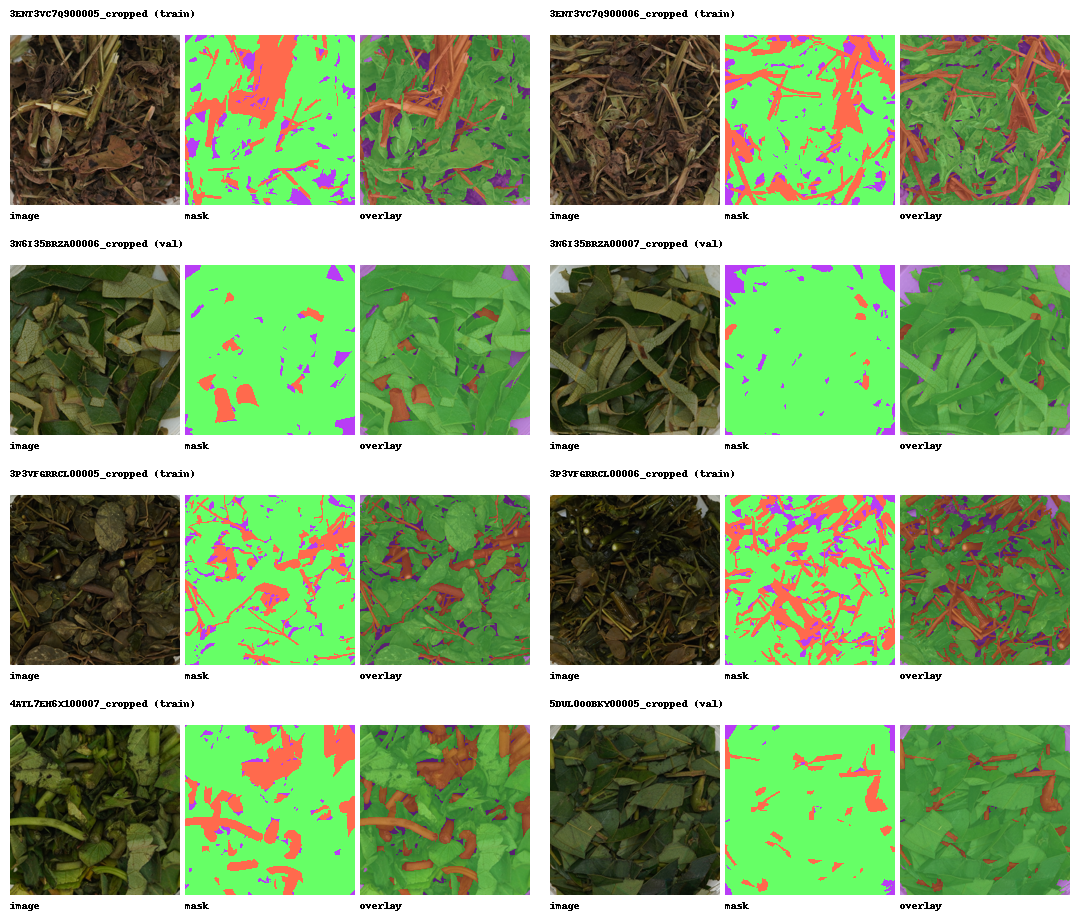

In [67]:
preview_dir = prepared_dir / "previews"
preview_dir.mkdir(exist_ok=True)

id_to_rgb = {
    cls["id"]: cls["rgb"]
    for cls in classes
}

def class_id_mask_to_rgb(mask_array, id_to_rgb):
    rgb = np.zeros((mask_array.shape[0], mask_array.shape[1], 3), dtype=np.uint8)
    
    for class_id, color in id_to_rgb.items():
        rgb[mask_array == class_id] = color
        
    return rgb

preview_rows = manifest.head(8)

tile_width = 540
tile_height = 230
columns = 2
rows_count = math.ceil(len(preview_rows) / columns)

sheet = Image.new(
    "RGB",
    (tile_width * columns, tile_height * rows_count),
    color=(245, 245, 245)
)

for idx, (_, row) in enumerate(preview_rows.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    mask = np.array(Image.open(row["class_id_mask_path"]))
    mask_rgb = Image.fromarray(class_id_mask_to_rgb(mask, id_to_rgb))
    
    image.thumbnail((170, 170))
    mask_rgb.thumbnail((170, 170), Image.Resampling.NEAREST)
    
    overlay = Image.blend(
        image.copy(),
        mask_rgb.resize(image.size, Image.Resampling.NEAREST),
        alpha=0.45
    )
    
    tile = Image.new("RGB", (tile_width, tile_height), color="white")
    draw = ImageDraw.Draw(tile)
    
    draw.text((10, 8), f"{row['sample_id']} ({row['split']})", fill=(0, 0, 0))
    
    tile.paste(image, (10, 35))
    tile.paste(mask_rgb, (185, 35))
    tile.paste(overlay, (360, 35))
    
    draw.text((10, 210), "image", fill=(0, 0, 0))
    draw.text((185, 210), "mask", fill=(0, 0, 0))
    draw.text((360, 210), "overlay", fill=(0, 0, 0))
    
    x = (idx % columns) * tile_width
    y = (idx // columns) * tile_height
    
    sheet.paste(tile, (x, y))
    
preview_path = preview_dir / "dataset_preview.jpg"
sheet.save(preview_path)

print("Saved dataset preview to:", preview_path)

display(sheet)

In [68]:
# Reload from disk
clean_dataset_dir = data_dir / "clean_dataset"

manifest_reloaded = pd.read_csv(clean_dataset_dir / "manifest.csv")

with open(clean_dataset_dir / "class_mapping.json", "r") as f:
    class_mapping_reloaded = json.load(f)

print("Clean dataset folder:", clean_dataset_dir)
print("Manifest rows:", len(manifest_reloaded))

print("\nSplit counts:")
print(manifest_reloaded["split"].value_counts())

print("\nClass mapping:")
print(json.dumps(class_mapping_reloaded, indent=2))

# Verify paths exist
missing_images = []
missing_masks = []

for _, row in manifest_reloaded.iterrows():
    if not Path(row["image_path"]).exists():
        missing_images.append(row["image_path"])
    if not Path(row["class_id_mask_path"]).exists():
        missing_masks.append(row["class_id_mask_path"])

print("\nMissing images:", len(missing_images))
print("Missing masks:", len(missing_masks))

manifest_reloaded.head()

Clean dataset folder: data\clean_dataset
Manifest rows: 70

Split counts:
train    49
val      11
test     10
Name: split, dtype: int64

Class mapping:
{
  "background": {
    "id": 0,
    "source_name": "background",
    "rgb": [
      0,
      0,
      0
    ]
  },
  "leaf": {
    "id": 1,
    "source_name": "leaf",
    "rgb": [
      102,
      255,
      102
    ]
  },
  "stem": {
    "id": 2,
    "source_name": "stem",
    "rgb": [
      255,
      106,
      77
    ]
  },
  "foreign_material": {
    "id": 3,
    "source_name": "unknown",
    "rgb": [
      184,
      61,
      245
    ]
  }
}

Missing images: 0
Missing masks: 0


,sample_id,image_path,class_id_mask_path,width,height,background_pixels,has_background,leaf_pixels,has_leaf,stem_pixels,has_stem,foreign_material_pixels,has_foreign_material,group_id,split
0,3ENT3VC7Q900005_cropped,data\Training_Images\3ENT3VC7Q900005_cropped.JPG,data\clean_dataset\class_id_masks\3ENT3VC7Q900...,2000,2000,0,0,2779166,1,832663,1,388171,1,3ENT3VC7Q9,train
1,3ENT3VC7Q900006_cropped,data\Training_Images\3ENT3VC7Q900006_cropped.JPG,data\clean_dataset\class_id_masks\3ENT3VC7Q900...,2000,2000,0,0,2642355,1,1048855,1,308790,1,3ENT3VC7Q9,train
2,3N6I35BRZA00006_cropped,data\Training_Images\3N6I35BRZA00006_cropped.JPG,data\clean_dataset\class_id_masks\3N6I35BRZA00...,2000,2000,0,0,3610966,1,200205,1,188829,1,3N6I35BRZA,val
3,3N6I35BRZA00007_cropped,data\Training_Images\3N6I35BRZA00007_cropped.JPG,data\clean_dataset\class_id_masks\3N6I35BRZA00...,2000,2000,0,0,3693133,1,54978,1,251889,1,3N6I35BRZA,val
4,3P3VFGRRCL00005_cropped,data\Training_Images\3P3VFGRRCL00005_cropped.JPG,data\clean_dataset\class_id_masks\3P3VFGRRCL00...,2000,2000,0,0,3053483,1,684410,1,262107,1,3P3VFGRRCL,train


### Model Training

In [3]:
# Set seeds for Python, NumPy, and PyTorch

seed = CONFIG["seed"]

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# %pip install segmentation-models-pytorch
# %pip install albumentations

In [5]:
import segmentation_models_pytorch as smp

In [6]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4,
)

In [7]:
# Input:  B × 3 × H × W
# Output: B × 4 × H × W logits
# Target: B × H × W integer class IDs

In [8]:
DATA_ROOT = Path("./data/clean_dataset")

manifest = pd.read_csv(DATA_ROOT / "manifest.csv")

with open(DATA_ROOT / "class_mapping.json") as f:
    class_mapping = json.load(f)

train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df = manifest[manifest["split"] == "test"].reset_index(drop=True)

In [9]:
assert set(train_df.group_id).isdisjoint(val_df.group_id)
assert set(train_df.group_id).isdisjoint(test_df.group_id)
assert set(val_df.group_id).isdisjoint(test_df.group_id)

assert len(train_df) + len(val_df) + len(test_df) == 70

#### Define augmentations

In [10]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.RandomCrop(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.OneOf([
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=1.0,
        ),
        A.HueSaturationValue(
            hue_shift_limit=8,
            sat_shift_limit=12,
            val_shift_limit=10,
            p=1.0,
        ),
    ], p=0.5),

    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.GaussNoise(p=1.0),
    ], p=0.15),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])

#### Build a patch dataset

In [11]:
from pathlib import Path

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset


class FeedPatchDataset(Dataset):
    def __init__(
        self,
        df,
        transform=None,
        patches_per_image=20,
        project_root=Path("."),
    ):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.patches_per_image = patches_per_image
        self.project_root = Path(project_root)
        self.valid_classes = {0, 1, 2, 3}

        if self.df.empty:
            raise ValueError("The supplied dataframe is empty.")

        required_columns = {
            "sample_id",
            "image_path",
            "class_id_mask_path",
        }

        missing_columns = required_columns - set(self.df.columns)

        if missing_columns:
            raise ValueError(
                f"Manifest is missing columns: {sorted(missing_columns)}"
            )

    def __len__(self):
        # For 49 images and 20 patches per image:
        # 49 × 20 = 980 samples per epoch
        return len(self.df) * self.patches_per_image

    def _resolve_path(self, path_value):
        """
        Resolve paths stored in the manifest.

        The current manifest contains paths such as:
        data\\Training_Images\\sample.JPG
        """
        path = Path(str(path_value))

        if not path.is_absolute():
            path = self.project_root / path

        return path

    def __getitem__(self, idx):
        # Reuse every parent image several times per epoch.
        # The random crop in the transform should produce a different
        # patch on each access.
        row_idx = idx % len(self.df)
        row = self.df.iloc[row_idx]

        img_path = self._resolve_path(row["image_path"])
        mask_path = self._resolve_path(row["class_id_mask_path"])

        # Load RGB image
        image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)

        if image is None:
            raise FileNotFoundError(
                f"Could not read RGB image: {img_path}"
            )

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load integer class-ID mask
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if mask is None:
            raise FileNotFoundError(
                f"Could not read mask: {mask_path}"
            )

        # Check spatial correspondence
        if image.shape[:2] != mask.shape:
            raise ValueError(
                f"Image-mask dimension mismatch for {row['sample_id']}: "
                f"image={image.shape[:2]}, mask={mask.shape}"
            )

        # Validate mask labels
        unique_values = set(np.unique(mask).tolist())
        unexpected_values = unique_values - self.valid_classes

        if unexpected_values:
            raise ValueError(
                f"Unexpected mask values {sorted(unexpected_values)} "
                f"in {mask_path}"
            )

        # Apply the same geometric transformation to image and mask
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # The transform should include ToTensorV2
        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).permute(2, 0, 1).float()

        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask)

        image = image.to(torch.float32)
        mask = mask.to(torch.long)

        return image, mask

In [12]:
train_df = manifest[
    manifest["split"] == "train"
].copy()

train_dataset = FeedPatchDataset(
    df=train_df,
    project_root=Path("."),
    transform=train_transform,
    patches_per_image=20,
)

In [13]:
train_df.head()

,sample_id,image_path,class_id_mask_path,width,height,background_pixels,has_background,leaf_pixels,has_leaf,stem_pixels,has_stem,foreign_material_pixels,has_foreign_material,group_id,split
0,3ENT3VC7Q900005_cropped,data\Training_Images\3ENT3VC7Q900005_cropped.JPG,data\clean_dataset\class_id_masks\3ENT3VC7Q900...,2000,2000,0,0,2779166,1,832663,1,388171,1,3ENT3VC7Q9,train
1,3ENT3VC7Q900006_cropped,data\Training_Images\3ENT3VC7Q900006_cropped.JPG,data\clean_dataset\class_id_masks\3ENT3VC7Q900...,2000,2000,0,0,2642355,1,1048855,1,308790,1,3ENT3VC7Q9,train
4,3P3VFGRRCL00005_cropped,data\Training_Images\3P3VFGRRCL00005_cropped.JPG,data\clean_dataset\class_id_masks\3P3VFGRRCL00...,2000,2000,0,0,3053483,1,684410,1,262107,1,3P3VFGRRCL,train
5,3P3VFGRRCL00006_cropped,data\Training_Images\3P3VFGRRCL00006_cropped.JPG,data\clean_dataset\class_id_masks\3P3VFGRRCL00...,2000,2000,0,0,2452090,1,1200831,1,347079,1,3P3VFGRRCL,train
6,4ATL7EH6X100007_cropped,data\Training_Images\4ATL7EH6X100007_cropped.JPG,data\clean_dataset\class_id_masks\4ATL7EH6X100...,2000,2000,0,0,2939394,1,946172,1,114434,1,4ATL7EH6X1,train


In [14]:
sample_image, sample_mask = train_dataset[0]

print("Dataset samples per epoch:", len(train_dataset))
print("Image shape:", sample_image.shape)
print("Image dtype:", sample_image.dtype)
print("Mask shape:", sample_mask.shape)
print("Mask dtype:", sample_mask.dtype)
print("Mask classes:", torch.unique(sample_mask).tolist())
print("Image range:", sample_image.min().item(), sample_image.max().item())

Dataset samples per epoch: 980
Image shape: torch.Size([3, 512, 512])
Image dtype: torch.float32
Mask shape: torch.Size([512, 512])
Mask dtype: torch.int64
Mask classes: [1, 2, 3]
Image range: -1.7240345478057861 1.1529239416122437


In [15]:
for idx in range(20):
    image, mask = train_dataset[idx]

    assert image.shape == (3, 512, 512)
    assert mask.shape == (512, 512)
    assert image.dtype == torch.float32
    assert mask.dtype == torch.int64
    assert set(torch.unique(mask).tolist()).issubset({0, 1, 2, 3})

print("Dataset sanity checks passed.")

Dataset sanity checks passed.


In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

In [17]:
batch_images, batch_masks = next(iter(train_loader))

print("Batch images:", batch_images.shape)
print("Batch masks:", batch_masks.shape)
print("Batch classes:", torch.unique(batch_masks).tolist())

Batch images: torch.Size([4, 3, 512, 512])
Batch masks: torch.Size([4, 512, 512])
Batch classes: [1, 2, 3]


### RGB baseline: loss, full-image validation, and checkpointing

In [18]:
from rgb_baseline import (
    CLASS_NAMES,
    CombinedSegmentationLoss,
    build_rgb_unet,
    compute_class_weights,
    evaluate_full_images,
    fit_rgb_baseline,
    load_best_checkpoint,
    split_class_summary,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

print("\nTraining distribution:")
display(split_class_summary(train_df))
print("Validation distribution:")
display(split_class_summary(val_df))

if int(val_df["has_background"].sum()) == 0:
    print("WARNING: validation has no background pixels; background IoU will be N/A.")

class_weights = compute_class_weights(train_df).to(device)
print("Class weights:", dict(zip(CLASS_NAMES, class_weights.cpu().tolist())))

model = build_rgb_unet(
    encoder_name=CONFIG["encoder"],
    num_classes=CONFIG["num_classes"],
).to(device)

criterion = CombinedSegmentationLoss(class_weights=class_weights)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)

Device: cpu

Training distribution:


,class,pixels,pixel_fraction,images_with_class,images
0,background,7324197,0.037368,3,49
1,leaf,148036360,0.755288,46,49
2,stem,30054086,0.153337,39,49
3,foreign_material,10585357,0.054007,49,49


Validation distribution:


,class,pixels,pixel_fraction,images_with_class,images
0,background,0,0.000000,0,11
1,leaf,39599728,0.899994,11,11
2,stem,2308921,0.052475,9,11
3,foreign_material,2091351,0.047531,11,11


Class weights: {'background': 1.5699156522750854, 'leaf': 0.3491983115673065, 'stem': 0.7750051021575928, 'foreign_material': 1.3058809041976929}


In [19]:
# One forward/loss pass before starting a long training run.
smoke_images, smoke_masks = next(iter(train_loader))
smoke_images = smoke_images.to(device)
smoke_masks = smoke_masks.to(device)

model.eval()
with torch.no_grad():
    smoke_logits = model(smoke_images)
    smoke_loss = criterion(smoke_logits, smoke_masks)

print("Logit shape:", smoke_logits.shape)
print("Target shape:", smoke_masks.shape)
print("Finite loss:", float(smoke_loss))
assert smoke_logits.shape == (smoke_images.shape[0], 4, 512, 512)
assert torch.isfinite(smoke_loss)

Logit shape: torch.Size([4, 4, 512, 512])
Target shape: torch.Size([4, 512, 512])
Finite loss: 3.274892807006836


### Train and select the best checkpoint by validation macro IoU

In [21]:
ARTIFACT_DIR = Path("./artifacts/rgb_baseline")

history = fit_rgb_baseline(
    model=model,
    train_loader=train_loader,
    val_df=val_df,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    output_dir=ARTIFACT_DIR,
    epochs=CONFIG["epochs"],
    patience=CONFIG["early_stopping_patience"],
    tile_size=CONFIG["patch_size"],
    stride=384,
    tile_batch_size=CONFIG["batch_size"],
    project_root=Path("."),
    config=CONFIG,
)

display(history.tail())

Epoch 001 | loss=1.3799 | val mIoU=0.3891 | background=0.000, leaf=0.885, stem=0.238, foreign_material=0.434
Epoch 002 | loss=1.2581 | val mIoU=0.4034 | background=0.000, leaf=0.909, stem=0.248, foreign_material=0.457
Epoch 003 | loss=1.2465 | val mIoU=0.4024 | background=0.000, leaf=0.910, stem=0.229, foreign_material=0.470
Epoch 004 | loss=1.2387 | val mIoU=0.3655 | background=0.000, leaf=0.820, stem=0.191, foreign_material=0.451
Epoch 005 | loss=1.1747 | val mIoU=0.3844 | background=0.000, leaf=0.865, stem=0.233, foreign_material=0.439
Epoch 006 | loss=1.1535 | val mIoU=0.4207 | background=0.000, leaf=0.918, stem=0.272, foreign_material=0.493
Epoch 007 | loss=1.1241 | val mIoU=0.4211 | background=0.000, leaf=0.897, stem=0.354, foreign_material=0.434
Epoch 008 | loss=1.0746 | val mIoU=0.3752 | background=0.000, leaf=0.888, stem=0.217, foreign_material=0.396
Epoch 009 | loss=1.0872 | val mIoU=0.4453 | background=0.000, leaf=0.923, stem=0.398, foreign_material=0.460
Epoch 010 | loss=1.

,epoch,train_loss,val_macro_iou,val_macro_dice,val_pixel_accuracy,learning_rate,val_iou_background,val_iou_leaf,val_iou_stem,val_iou_foreign_material
29,30,0.582337,0.475697,0.567410,0.930875,0.000013,0.0,0.930263,0.437372,0.535154
30,31,0.598556,0.471642,0.563525,0.935283,0.000013,0.0,0.935482,0.438583,0.512503
31,32,0.584709,0.462756,0.558049,0.904731,0.000006,0.0,0.902906,0.423603,0.524515
32,33,0.560300,0.471520,0.563940,0.928520,0.000006,0.0,0.927720,0.433827,0.524535
33,34,0.582090,0.473284,0.564842,0.932164,0.000006,0.0,0.931187,0.423486,0.538462


### Final evaluation on the annotated test split

In [22]:
checkpoint = load_best_checkpoint(
    model,
    ARTIFACT_DIR / "best_rgb_unet.pt",
    device,
)

test_metrics, per_image_test_metrics = evaluate_full_images(
    model,
    test_df,
    device,
    project_root=Path("."),
    tile_size=CONFIG["patch_size"],
    stride=384,
    tile_batch_size=CONFIG["batch_size"],
)

test_metric_table = pd.DataFrame(test_metrics["per_class"]).T
display(test_metric_table)
print("Test macro IoU:", test_metrics["macro_iou"])
print("Test macro Dice:", test_metrics["macro_dice"])
print("Test pixel accuracy:", test_metrics["pixel_accuracy"])

per_image_test_metrics.to_csv(ARTIFACT_DIR / "per_image_test_metrics.csv", index=False)
with open(ARTIFACT_DIR / "test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2, allow_nan=True)

,iou,dice,precision,recall,support_pixels
background,0.000000,0.000000,0.000000,0.000000,3545067.0
leaf,0.709578,0.830121,0.814893,0.845928,29466551.0
stem,0.356149,0.525236,0.464306,0.604573,5432607.0
foreign_material,0.408684,0.580235,0.483228,0.725973,1555775.0


Test macro IoU: 0.36860273793435694
Test macro Dice: 0.4838978845194861
Test pixel accuracy: 0.733511075
